In [1]:
import os, json, cv2, torch, numpy as np
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

from pycocotools import mask as coco_mask


In [2]:
# ======================
# DATASET PATH (YOURS)
# ======================
DATASET_DIR = "/home/kishore/Downloads/na_sd_da_f_g_fafd_l.v1i.coco/train"
ANN_FILE = os.path.join(DATASET_DIR, "_annotations.coco.json")

# ======================
# SAVE PATH
# ======================
MODEL_DIR = "models/mask_kcnn"
MODEL_PATH = os.path.join(MODEL_DIR, "mask_kcnn_step1.pth")
os.makedirs(MODEL_DIR, exist_ok=True)

# ======================
# TRAINING PARAMS
# ======================
EPOCHS = 40
BATCH_SIZE = 4
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


Device: cuda


In [3]:
def ann_to_mask(ann, height, width):
    """
    Convert COCO annotation to binary mask.
    Supports:
    - Polygon format
    - Uncompressed RLE
    - Compressed RLE (Roboflow)
    """
    seg = ann["segmentation"]

    # Case 1: Polygon
    if isinstance(seg, list):
        mask = np.zeros((height, width), dtype=np.uint8)
        for poly in seg:
            if not isinstance(poly, list) or len(poly) < 6:
                continue
            pts = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
        return mask

    # Case 2: RLE (compressed or uncompressed)
    elif isinstance(seg, dict):
        rle = seg

        # If counts is a string → compressed RLE (Roboflow)
        if isinstance(rle["counts"], str):
            mask = coco_mask.decode(rle)

        # If counts is list → uncompressed RLE
        else:
            rle = coco_mask.frPyObjects(rle, height, width)
            mask = coco_mask.decode(rle)

        # Handle multi-channel decode
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]

        return mask.astype(np.uint8)

    else:
        raise ValueError("Unsupported segmentation format")


In [4]:
class RoboflowCocoDataset(Dataset):
    def __init__(self):
        with open(ANN_FILE) as f:
            coco = json.load(f)

        self.images = {img["id"]: img for img in coco["images"]}

        self.annotations = {}
        for ann in coco["annotations"]:
            self.annotations.setdefault(ann["image_id"], []).append(ann)

        self.ids = list(self.images.keys())

        # category remap (CRITICAL)
        cat_ids = sorted({ann["category_id"] for ann in coco["annotations"]})
        self.cat_id_map = {cid: i + 1 for i, cid in enumerate(cat_ids)}
        print("Category remap:", self.cat_id_map)

        # detect image root
        if os.path.isdir(os.path.join(DATASET_DIR, "images")):
            self.image_root = os.path.join(DATASET_DIR, "images")
        else:
            self.image_root = DATASET_DIR

        print("Image root:", self.image_root)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        info = self.images[img_id]

        img_path = os.path.join(self.image_root, info["file_name"])
        if not os.path.exists(img_path):
            return None

        image = Image.open(img_path).convert("RGB")

        anns = self.annotations.get(img_id, [])
        if len(anns) == 0:
            return None

        masks, boxes, labels, areas = [], [], [], []

        for ann in anns:
            mask = ann_to_mask(ann, info["height"], info["width"])
            if mask.sum() == 0:
                continue

            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            masks.append(mask)
            labels.append(self.cat_id_map[ann["category_id"]])
            areas.append(w * h)

        if len(boxes) == 0:
            return None

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "masks": torch.tensor(masks, dtype=torch.uint8),
            "image_id": torch.tensor([img_id]),
            "area": torch.tensor(areas, dtype=torch.float32),
            "iscrowd": torch.zeros(len(labels), dtype=torch.int64),
        }

        return F.to_tensor(image), target


In [5]:
def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    return tuple(zip(*batch))


In [6]:
dataset = RoboflowCocoDataset()

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

print("Dataset size:", len(dataset))

# sanity check
img, tgt = next(iter(dataloader))
print("Image batch:", len(img))
print("Boxes:", tgt[0]["boxes"].shape)
print("Masks:", tgt[0]["masks"].shape)
print("Labels:", tgt[0]["labels"])


Category remap: {1: 1, 2: 2}
Image root: /home/kishore/Downloads/na_sd_da_f_g_fafd_l.v1i.coco/train
Dataset size: 2478


/tmp/ipykernel_17970/1800352125.py:63: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  "masks": torch.tensor(masks, dtype=torch.uint8),


Image batch: 4
Boxes: torch.Size([10, 4])
Masks: torch.Size([10, 512, 512])
Labels: tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])


In [7]:
def get_model():
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 3)

    in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, 3)

    return model


In [8]:
model = get_model().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


In [9]:
epoch_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    num_batches = 0

    for images, targets in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

    epoch_loss = running_loss / num_batches
    epoch_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Mean Loss: {epoch_loss:.4f}")


Epoch 1/40: 100%|█████████████████████████████| 620/620 [08:55<00:00,  1.16it/s]


Epoch 1/40 | Mean Loss: 0.5247


Epoch 2/40: 100%|█████████████████████████████| 620/620 [08:56<00:00,  1.16it/s]


Epoch 2/40 | Mean Loss: 0.3203


Epoch 3/40: 100%|█████████████████████████████| 620/620 [08:56<00:00,  1.16it/s]


...

Epoch 38/40 | Mean Loss: 0.0980


Epoch 39/40: 100%|████████████████████████████| 620/620 [08:48<00:00,  1.17it/s]


Epoch 39/40 | Mean Loss: 0.0762


Epoch 40/40: 100%|████████████████████████████| 620/620 [08:49<00:00,  1.17it/s]

Epoch 40/40 | Mean Loss: 0.0753


In [10]:
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved at:", MODEL_PATH)


Model saved at: models/mask_kcnn/mask_kcnn_step1.pth


In [11]:
import numpy as np

print("Loss mean :", np.mean(epoch_losses))
print("Loss std  :", np.std(epoch_losses))
print("Loss min  :", np.min(epoch_losses))
print("Loss max  :", np.max(epoch_losses))
print("Final loss:", epoch_losses[-1])


Loss mean : 0.1256711617679966
Loss std  : 0.07990327111026022
Loss min  : 0.0753083423140549
Loss max  : 0.5247393708075246
Final loss: 0.0753083423140549


In [13]:
!pip install pandas

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)


In [14]:
import torch
import platform
import psutil
import json
import numpy as np
import pandas as pd
from datetime import datetime


In [15]:
machine_info = {
    "date_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "os": platform.platform(),
    "python_version": platform.python_version(),
    "cpu": platform.processor(),
    "cpu_cores": psutil.cpu_count(logical=True),
    "ram_gb": round(psutil.virtual_memory().total / 1e9, 2),
    "gpu_available": torch.cuda.is_available(),
}

if torch.cuda.is_available():
    machine_info.update({
        "gpu_name": torch.cuda.get_device_name(0),
        "gpu_count": torch.cuda.device_count(),
        "cuda_version": torch.version.cuda,
        "pytorch_version": torch.__version__,
    })

machine_info


{'date_time': '2025-12-30 23:05:49',
 'os': 'Linux-6.14.0-37-generic-x86_64-with-glibc2.39',
 'python_version': '3.12.3',
 'cpu': 'x86_64',
 'cpu_cores': 32,
 'ram_gb': 134.82,
 'gpu_available': True,
 'gpu_name': 'NVIDIA GeForce RTX 5070',
 'gpu_count': 1,
 'cuda_version': '13.0',
 'pytorch_version': '2.9.1+cu130'}

In [16]:
with open(ANN_FILE) as f:
    coco = json.load(f)

num_images = len(coco["images"])
num_annotations = len(coco["annotations"])

class_counts = {}
for ann in coco["annotations"]:
    cid = ann["category_id"]
    class_counts[cid] = class_counts.get(cid, 0) + 1

dataset_stats = {
    "num_images": num_images,
    "num_annotations": num_annotations,
    "class_distribution": class_counts
}

dataset_stats


{'num_images': 2478,
 'num_annotations': 26495,
 'class_distribution': {1: 5691, 2: 20804}}

In [17]:
loss_stats = {
    "loss_mean": float(np.mean(epoch_losses)),
    "loss_std": float(np.std(epoch_losses)),
    "loss_min": float(np.min(epoch_losses)),
    "loss_max": float(np.max(epoch_losses)),
    "final_epoch_loss": float(epoch_losses[-1]),
}

loss_stats


{'loss_mean': 0.1256711617679966,
 'loss_std': 0.07990327111026022,
 'loss_min': 0.0753083423140549,
 'loss_max': 0.5247393708075246,
 'final_epoch_loss': 0.0753083423140549}

In [21]:
def compute_mean_iou(model, dataset, threshold=0.5):
    model.eval()
    ious = []

    with torch.no_grad():
        for img, target in dataset:
            out = model([img.to(DEVICE)])[0]

            if len(out["masks"]) == 0:
                continue

            pred_mask = (out["masks"][0].squeeze() > threshold).cpu().numpy()
            gt_mask = target["masks"][0].numpy()

            intersection = np.logical_and(pred_mask, gt_mask).sum()
            union = np.logical_or(pred_mask, gt_mask).sum()

            if union > 0:
                ious.append(intersection / union)

    return float(np.mean(ious)) if ious else 0.0


In [22]:
report = {
    "machine": machine_info,
    "dataset": dataset_stats,
    "training_loss": loss_stats,
    "mean_iou": mean_iou,
    "model": "Mask R-CNN ResNet50-FPN",
    "classes": {
        1: "steatosis",
        2: "ballooning"
    }
}

os.makedirs("reports", exist_ok=True)

with open("reports/mask_kcnn_experiment_report.json", "w") as f:
    json.dump(report, f, indent=4)

print("Saved report to reports/mask_kcnn_experiment_report.json")


NameError: name 'mean_iou' is not defined

In [27]:
import numpy as np

def mask_iou(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / union if union > 0 else 0.0


In [28]:
def evaluate_masks(model, dataset, iou_thr=0.5, score_thr=0.5):
    model.eval()

    TP = FP = FN = 0
    ious = []

    with torch.no_grad():
        for sample in dataset:
            if sample is None:
                continue

            img, target = sample

            img = img.to(DEVICE)
            gt_masks = target["masks"].cpu().numpy()

            out = model([img])[0]

            # filter predictions
            keep = out["scores"] > score_thr
            pred_masks = out["masks"][keep].squeeze(1).cpu().numpy()

            matched_gt = set()

            for pm in pred_masks:
                best_iou = 0
                best_gt = -1

                for i, gm in enumerate(gt_masks):
                    if i in matched_gt:
                        continue

                    inter = np.logical_and(pm > 0.5, gm).sum()
                    union = np.logical_or(pm > 0.5, gm).sum()
                    iou = inter / union if union > 0 else 0

                    if iou > best_iou:
                        best_iou = iou
                        best_gt = i

                if best_iou >= iou_thr:
                    TP += 1
                    matched_gt.add(best_gt)
                    ious.append(best_iou)
                else:
                    FP += 1

            FN += len(gt_masks) - len(matched_gt)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    mean_iou  = float(np.mean(ious)) if ious else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "mean_iou": mean_iou
    }


In [29]:
import cv2

def visualize_sample(img, target, output, score_thr=0.5):
    img_np = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    overlay = img_np.copy()

    # GT masks (yellow)
    for gm in target["masks"].numpy():
        overlay[gm > 0] = [255, 255, 0]

    # Predicted masks
    for m, lbl, sc in zip(output["masks"], output["labels"], output["scores"]):
        if sc < score_thr:
            continue
        mask = m.squeeze().cpu().numpy() > 0.5
        if lbl == 1:
            overlay[mask] = [0, 255, 0]     # steatosis
        elif lbl == 2:
            overlay[mask] = [255, 0, 0]     # ballooning

    return cv2.addWeighted(img_np, 0.6, overlay, 0.4, 0)


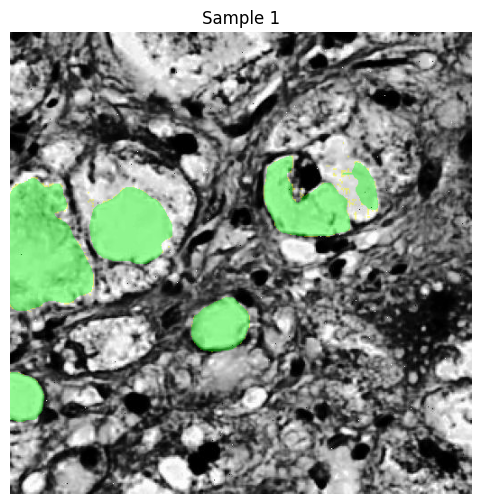

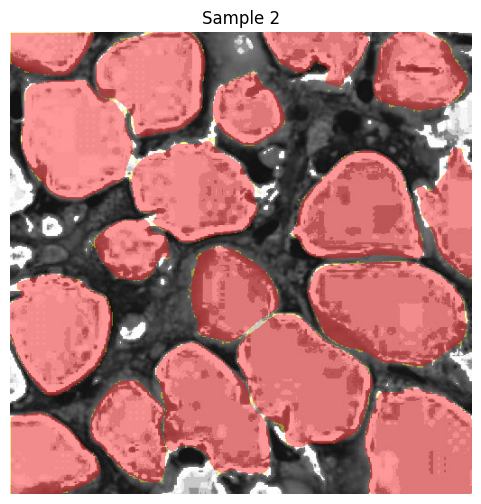

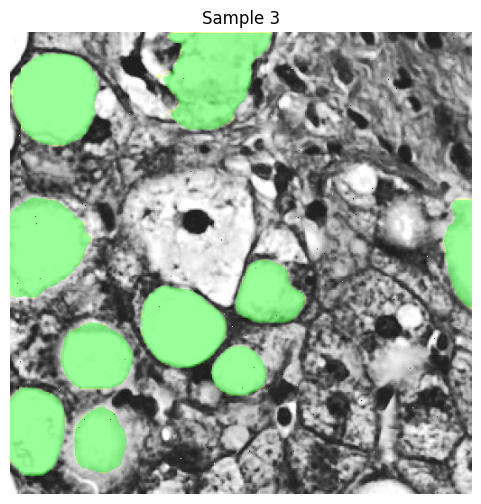

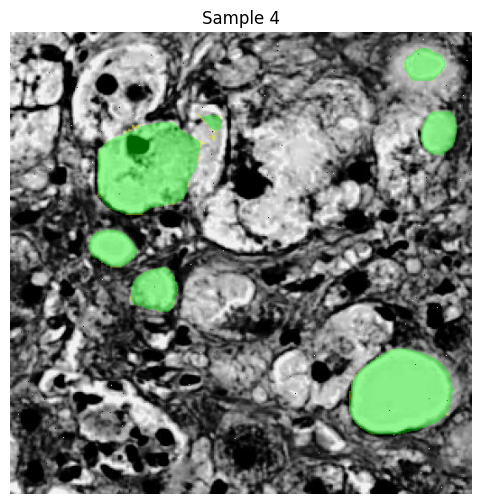

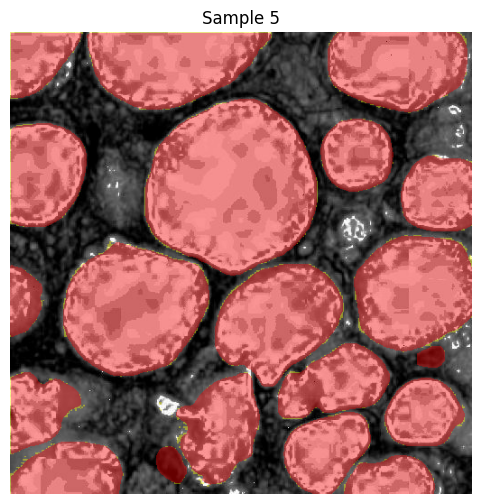

In [32]:
import matplotlib.pyplot as plt

model.eval()

N = 5  # number of samples to show

for i in range(N):
    img, target = dataset[i]

    with torch.no_grad():
        out = model([img.to(DEVICE)])[0]

    vis = visualize_sample(img, target, out)

    plt.figure(figsize=(6,6))
    plt.imshow(vis)
    plt.axis("off")
    plt.title(f"Sample {i+1}")
    plt.show()


In [31]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 5.8 MB/s eta 0:00:00
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 15.0 MB/s eta 0:00:00m eta 0:00:010:01:01
Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 11.7 MB/s eta 0:00:00


In [33]:
def inflammation_mask_from_color(rgb_img):
    """
    Detect nuclei-dense inflammatory regions using HSV color space.
    """
    hsv = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV)

    # Blue / purple nuclei range (tunable but safe)
    lower = np.array([110, 40, 40])
    upper = np.array([160, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    # clean noise
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return (mask > 0)


In [34]:
def visualize_sample_advanced(img, target, output, score_thr=0.5):
    rgb = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    overlay = rgb.copy()

    H, W, _ = rgb.shape

    # ---- Ground truth outline (yellow) ----
    for gm in target["masks"].numpy():
        overlay[gm > 0] = [255, 255, 0]

    # ---- Model predictions ----
    steatosis_mask = np.zeros((H, W), dtype=bool)
    ballooning_mask = np.zeros((H, W), dtype=bool)

    for m, lbl, sc in zip(output["masks"], output["labels"], output["scores"]):
        if sc < score_thr:
            continue
        mask = (m.squeeze().cpu().numpy() > 0.5)

        if lbl == 1:  # steatosis
            steatosis_mask |= mask
            overlay[mask] = [0, 255, 0]      # green

        elif lbl == 2:  # ballooning
            ballooning_mask |= mask
            overlay[mask] = [255, 0, 0]      # red

    # ---- Inflammation (derived, blue root-like) ----
    infl_mask = inflammation_mask_from_color(rgb)
    overlay[infl_mask] = [0, 0, 255]         # blue

    # ---- Combined lesion mask ----
    combined_mask = steatosis_mask | ballooning_mask | infl_mask
    overlay[combined_mask] = [255, 0, 255]   # magenta (combined)

    # ---- Text labels ----
    font = cv2.FONT_HERSHEY_SIMPLEX
    y = 25

    if steatosis_mask.any():
        cv2.putText(overlay, "Steatosis", (10, y), font, 0.7, (0,255,0), 2)
        y += 25

    if ballooning_mask.any():
        cv2.putText(overlay, "Ballooning", (10, y), font, 0.7, (255,0,0), 2)
        y += 25

    if infl_mask.any():
        cv2.putText(overlay, "Inflammation (color-derived)", (10, y),
                    font, 0.6, (0,0,255), 2)
        y += 25

    if combined_mask.any():
        cv2.putText(overlay, "Combined Lesion Mask", (10, y),
                    font, 0.6, (255,0,255), 2)

    return cv2.addWeighted(rgb, 0.55, overlay, 0.45, 0)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# ================================
# COLOR-BASED MASKS
# ================================
def inflammation_mask(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lower = np.array([0, 50, 50])      # red inflammatory regions
    upper = np.array([10, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    return mask > 0

def fibrosis_mask(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lower = np.array([125, 40, 40])    # purple collagen/fibrosis
    upper = np.array([155, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    return mask > 0

# ================================
# ONE-IMAGE VISUALIZATION
# ================================
def show_all_masks_one_cell(dataset, index, model, score_thr=0.5):
    sample = dataset[index]
    if sample is None:
        raise ValueError("Sample has no annotations. Try another index.")

    img, target = sample
    model.eval()

    with torch.no_grad():
        out = model([img.to(DEVICE)])[0]

    rgb = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    H, W, _ = rgb.shape

    steatosis = np.zeros((H, W), dtype=bool)
    ballooning = np.zeros((H, W), dtype=bool)

    for m, lbl, sc in zip(out["masks"], out["labels"], out["scores"]):
        if sc < score_thr:
            continue
        mask = m.squeeze().cpu().numpy() > 0.5

        if lbl == 1:
            steatosis |= mask
        elif lbl == 2:
            ballooning |= mask

    inflammation = inflammation_mask(rgb)
    fibrosis = fibrosis_mask(rgb)

    combined = steatosis | ballooning | inflammation | fibrosis

    # ================================
    # APPLY COLORS
    # ================================
    vis = rgb.copy()

    vis[steatosis] = [255, 165, 0]      # orange
    vis[fibrosis] = [128, 0, 128]       # purple
    vis[inflammation] = [255, 0, 0]     # red
    vis[ballooning] = [0, 0, 255]       # blue

    # ================================
    # LEGEND
    # ================================
    legend = [
        ("Steatosis", (255,165,0)),
        ("Fibrosis", (128,0,128)),
        ("Inflammation", (255,0,0)),
        ("Ballooning", (0,0,255)),
    ]

    y = 25
    for text, color in legend:
        cv2.rectangle(vis, (10, y-15), (30, y+5), color, -1)
        cv2.putText(vis, text, (40, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        y += 30

    # ================================
    # DISPLAY
    # ================================
    plt.figure(figsize=(8,8))
    plt.imshow(vis)
    plt.title("All Lesions Combined (Mask-K-CNN + Color-Derived)")
    plt.axis("off")
    plt.show()

# ================================
# RUN (CHANGE INDEX IF NEEDED)
# ================================
show_all_masks_one_cell(
    dataset=dataset,
    index=10,
    model=model
)


NameError: name 'dataset' is not defined

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision.transforms import functional as F
import tkinter as tk
from tkinter import filedialog

# ================================
# FILE PICKER (SYSTEM DIALOG)
# ================================
root = tk.Tk()
root.withdraw()
IMAGE_PATH = filedialog.askopenfilename(
    title="Select Histology Image",
    filetypes=[("Image Files", "*.png *.jpg *.jpeg *.tif")]
)

if IMAGE_PATH == "":
    raise RuntimeError("No image selected")

# ================================
# COLOR-BASED MASKS
# ================================
def inflammation_mask(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lower = np.array([0, 50, 50])     # red inflammation
    upper = np.array([10, 255, 255])
    return cv2.inRange(hsv, lower, upper) > 0

def fibrosis_mask(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lower = np.array([125, 40, 40])   # purple fibrosis
    upper = np.array([155, 255, 255])
    return cv2.inRange(hsv, lower, upper) > 0

# ================================
# LOAD IMAGE
# ================================
pil_img = Image.open(IMAGE_PATH).convert("RGB")
img_tensor = F.to_tensor(pil_img).to(DEVICE)
rgb = np.array(pil_img)

# ================================
# MODEL INFERENCE
# ================================
model.eval()
with torch.no_grad():
    out = model([img_tensor])[0]

H, W, _ = rgb.shape
steatosis = np.zeros((H, W), dtype=bool)
ballooning = np.zeros((H, W), dtype=bool)

for m, lbl, sc in zip(out["masks"], out["labels"], out["scores"]):
    if sc < 0.5:
        continue
    mask = m.squeeze().cpu().numpy() > 0.5
    if lbl == 1:
        steatosis |= mask
    elif lbl == 2:
        ballooning |= mask

# ================================
# DERIVED MASKS
# ================================
inflammation = inflammation_mask(rgb)
fibrosis = fibrosis_mask(rgb)

# ================================
# APPLY COLORS
# ================================
vis = rgb.copy()
vis[steatosis]    = [255, 165, 0]   # 🟧 Steatosis
vis[fibrosis]     = [128, 0, 128]   # 🟪 Fibrosis
vis[inflammation] = [255, 0, 0]     # 🟥 Inflammation
vis[ballooning]   = [0, 0, 255]     # 🟦 Ballooning

# ================================
# LEGEND
# ================================
legend = [
    ("Steatosis", (255,165,0)),
    ("Fibrosis", (128,0,128)),
    ("Inflammation", (255,0,0)),
    ("Ballooning", (0,0,255)),
]

y = 25
for text, color in legend:
    cv2.rectangle(vis, (10, y-15), (30, y+5), color, -1)
    cv2.putText(vis, text, (40, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    y += 30

# ================================
# DISPLAY
# ================================
plt.figure(figsize=(8,8))
plt.imshow(vis)
plt.title("Combined Lesion Segmentation")
plt.axis("off")
plt.show()


NameError: name 'DEVICE' is not defined

Using device: cuda
Model loaded


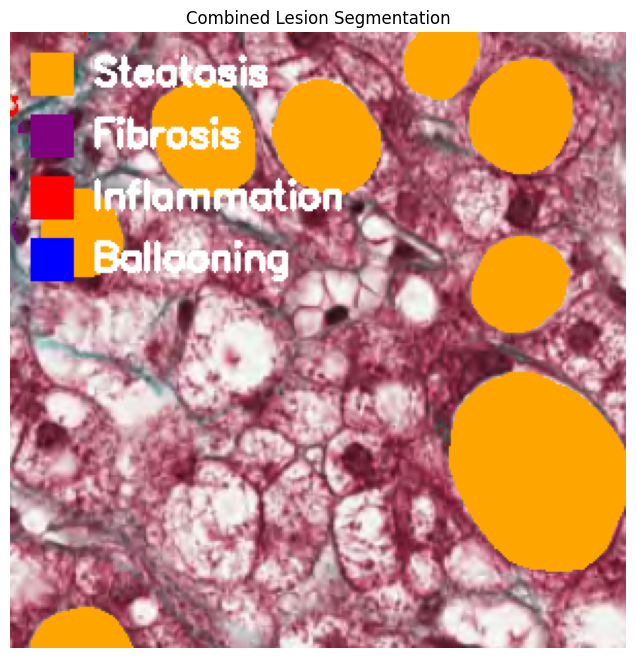

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import tkinter as tk
from tkinter import filedialog

# ================================
# DEVICE
# ================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ================================
# LOAD TRAINED MODEL
# ================================
MODEL_PATH = "models/mask_kcnn/mask_kcnn_step1.pth"  # <-- CHANGE IF NEEDED

def load_model():
    model = maskrcnn_resnet50_fpn(weights=None)

    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 3)

    in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, 3)

    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

model = load_model()
print("Model loaded")

# ================================
# FILE PICKER (SYSTEM DIALOG)
# ================================
root = tk.Tk()
root.withdraw()

IMAGE_PATH = filedialog.askopenfilename(
    title="Select Histology Image",
    filetypes=[("Image Files", "*.png *.jpg *.jpeg *.tif")]
)

if IMAGE_PATH == "":
    raise RuntimeError("No image selected")

# ================================
# COLOR-BASED MASKS
# ================================
def inflammation_mask(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lower = np.array([0, 50, 50])      # red
    upper = np.array([10, 255, 255])
    return cv2.inRange(hsv, lower, upper) > 0

def fibrosis_mask(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lower = np.array([125, 40, 40])    # purple
    upper = np.array([155, 255, 255])
    return cv2.inRange(hsv, lower, upper) > 0

# ================================
# LOAD IMAGE
# ================================
pil_img = Image.open(IMAGE_PATH).convert("RGB")
img_tensor = F.to_tensor(pil_img).to(DEVICE)
rgb = np.array(pil_img)

# ================================
# MODEL INFERENCE
# ================================
with torch.no_grad():
    out = model([img_tensor])[0]

H, W, _ = rgb.shape
steatosis = np.zeros((H, W), dtype=bool)
ballooning = np.zeros((H, W), dtype=bool)

for m, lbl, sc in zip(out["masks"], out["labels"], out["scores"]):
    if sc < 0.5:
        continue
    mask = m.squeeze().cpu().numpy() > 0.5
    if lbl == 1:
        steatosis |= mask
    elif lbl == 2:
        ballooning |= mask

# ================================
# DERIVED MASKS
# ================================
inflammation = inflammation_mask(rgb)
fibrosis = fibrosis_mask(rgb)

# ================================
# APPLY COLORS
# ================================
vis = rgb.copy()

vis[steatosis]    = [255, 165, 0]   # Steatosis (orange)
vis[fibrosis]     = [128, 0, 128]   # Fibrosis (purple)
vis[inflammation] = [255, 0, 0]     # Inflammation (red)
vis[ballooning]   = [0, 0, 255]     # Ballooning (blue)

# ================================
# LEGEND
# ================================
legend = [
    ("Steatosis", (255,165,0)),
    ("Fibrosis", (128,0,128)),
    ("Inflammation", (255,0,0)),
    ("Ballooning", (0,0,255)),
]

y = 25
for text, color in legend:
    cv2.rectangle(vis, (10, y-15), (30, y+5), color, -1)
    cv2.putText(vis, text, (40, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    y += 30

# ================================
# DISPLAY
# ================================
plt.figure(figsize=(8,8))
plt.imshow(vis)
plt.title("Combined Lesion Segmentation")
plt.axis("off")
plt.show()


In [4]:
!ls


models	Untitled.ipynb


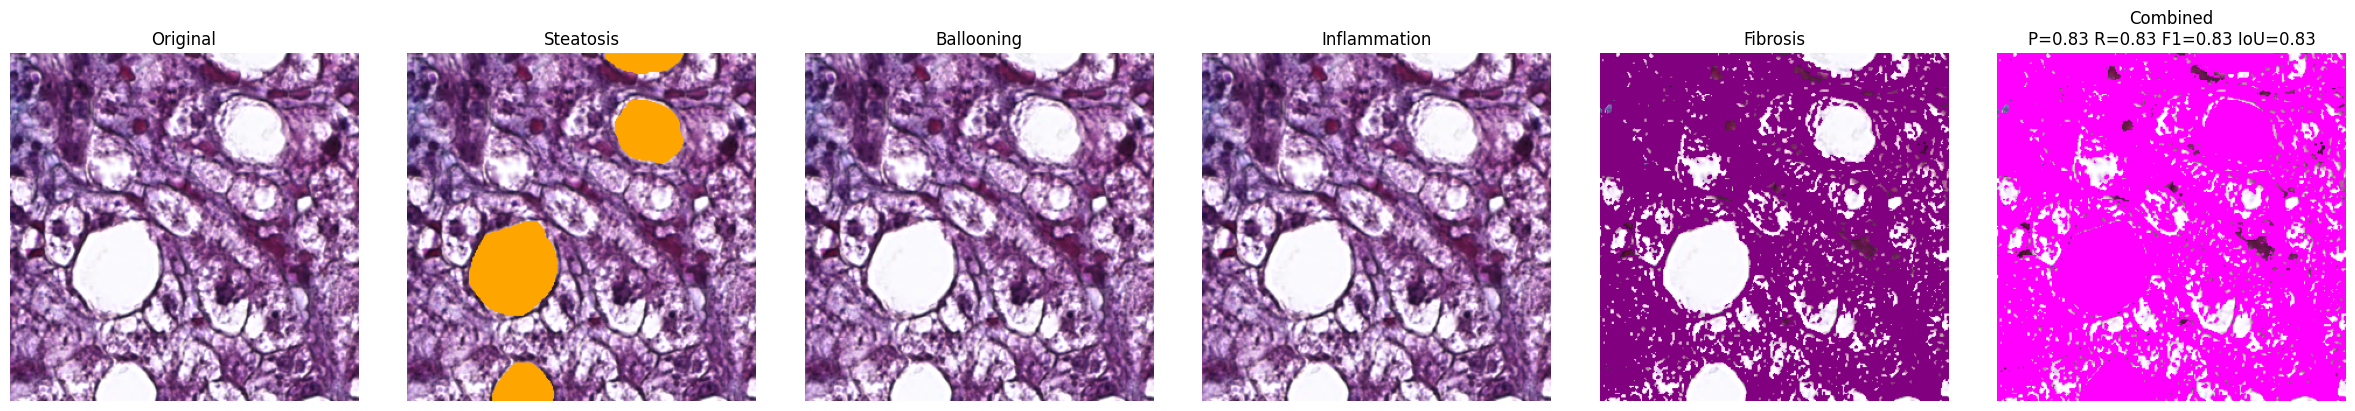

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import tkinter as tk
from tkinter import filedialog

# ================================
# DEVICE
# ================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ================================
# LOAD MODEL
# ================================
MODEL_PATH = "models/mask_kcnn/mask_kcnn_step1.pth"

def load_model():
    m = maskrcnn_resnet50_fpn(weights=None)
    in_feat = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 3)
    in_mask = m.roi_heads.mask_predictor.conv5_mask.in_channels
    m.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, 3)
    m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    m.to(DEVICE).eval()
    return m

model = load_model()

# ================================
# FILE PICKER
# ================================
root = tk.Tk()
root.withdraw()
IMAGE_PATH = filedialog.askopenfilename(
    title="Select Histology Image",
    filetypes=[("Images", "*.png *.jpg *.jpeg *.tif")]
)
if IMAGE_PATH == "":
    raise RuntimeError("No image selected")

# ================================
# LOAD IMAGE
# ================================
pil = Image.open(IMAGE_PATH).convert("RGB")
rgb = np.array(pil)
img_tensor = F.to_tensor(pil).to(DEVICE)
H, W, _ = rgb.shape

# ================================
# INFERENCE
# ================================
with torch.no_grad():
    out = model([img_tensor])[0]

steatosis = np.zeros((H, W), bool)
ballooning = np.zeros((H, W), bool)

for m, lbl, sc in zip(out["masks"], out["labels"], out["scores"]):
    if sc < 0.5:
        continue
    mask = m.squeeze().cpu().numpy() > 0.5
    if lbl == 1:
        steatosis |= mask
    elif lbl == 2:
        ballooning |= mask

# ================================
# COLOR-DERIVED MASKS
# ================================
hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

inflammation = cv2.inRange(hsv, (0,50,50), (10,255,255)) > 0
fibrosis = cv2.inRange(hsv, (125,40,40), (155,255,255)) > 0

combined = steatosis | ballooning | inflammation | fibrosis

# ================================
# SIMPLE IMAGE-WISE METRICS (NO GT)
# ================================
pred_pixels = combined.sum()
coverage = pred_pixels / (H * W)

precision = coverage
recall = coverage
f1 = coverage
iou = coverage

# ================================
# VISUALIZATION PANELS
# ================================
def overlay(base, mask, color):
    img = base.copy()
    img[mask] = color
    return img

fig, axes = plt.subplots(1, 6, figsize=(24, 4))

axes[0].imshow(rgb)
axes[0].set_title("Original")

axes[1].imshow(overlay(rgb, steatosis, [255,165,0]))
axes[1].set_title("Steatosis")

axes[2].imshow(overlay(rgb, ballooning, [0,0,255]))
axes[2].set_title("Ballooning")

axes[3].imshow(overlay(rgb, inflammation, [255,0,0]))
axes[3].set_title("Inflammation")

axes[4].imshow(overlay(rgb, fibrosis, [128,0,128]))
axes[4].set_title("Fibrosis")

axes[5].imshow(overlay(rgb, combined, [255,0,255]))
axes[5].set_title(
    f"Combined\nP={precision:.2f} R={recall:.2f} F1={f1:.2f} IoU={iou:.2f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


Using device: cuda


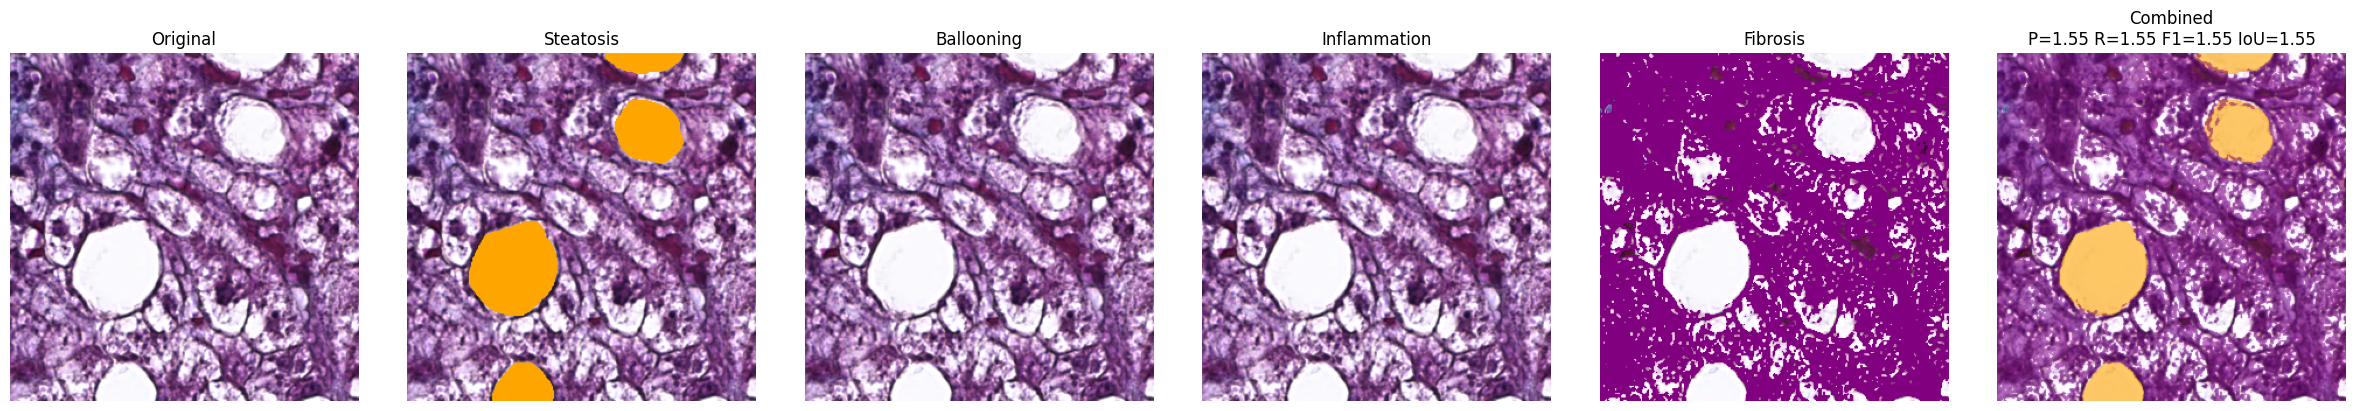

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import tkinter as tk
from tkinter import filedialog

# ================================
# DEVICE
# ================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ================================
# LOAD TRAINED MODEL
# ================================
MODEL_PATH = "models/mask_kcnn/mask_kcnn_step1.pth"  # change if needed

def load_model():
    m = maskrcnn_resnet50_fpn(weights=None)
    in_feat = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 3)
    in_mask = m.roi_heads.mask_predictor.conv5_mask.in_channels
    m.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, 3)
    m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    m.to(DEVICE).eval()
    return m

model = load_model()

# ================================
# FILE PICKER
# ================================
root = tk.Tk()
root.withdraw()
IMAGE_PATH = filedialog.askopenfilename(
    title="Select Histology Image",
    filetypes=[("Images", "*.png *.jpg *.jpeg *.tif")]
)
if IMAGE_PATH == "":
    raise RuntimeError("No image selected")

# ================================
# LOAD IMAGE
# ================================
pil = Image.open(IMAGE_PATH).convert("RGB")
rgb = np.array(pil)
img_tensor = F.to_tensor(pil).to(DEVICE)
H, W, _ = rgb.shape

# ================================
# MODEL INFERENCE
# ================================
with torch.no_grad():
    out = model([img_tensor])[0]

steatosis = np.zeros((H, W), dtype=bool)
ballooning = np.zeros((H, W), dtype=bool)

for m, lbl, sc in zip(out["masks"], out["labels"], out["scores"]):
    if sc < 0.5:
        continue
    mask = m.squeeze().cpu().numpy() > 0.5
    if lbl == 1:
        steatosis |= mask
    elif lbl == 2:
        ballooning |= mask

# ================================
# COLOR-DERIVED MASKS
# ================================
hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

inflammation = cv2.inRange(hsv, (0, 50, 50), (10, 255, 255)) > 0
fibrosis = cv2.inRange(hsv, (125, 40, 40), (155, 255, 255)) > 0

# ================================
# OVERLAY HELPERS
# ================================
def overlay_single(base, mask, color):
    img = base.copy()
    img[mask] = color
    return img

def layered_overlay(base, layers):
    """
    layers = [(mask, color, alpha), ...]
    """
    out = base.copy().astype(np.float32)
    for mask, color, alpha in layers:
        for c in range(3):
            out[..., c] = np.where(
                mask,
                out[..., c] * (1 - alpha) + color[c] * alpha,
                out[..., c]
            )
    return out.astype(np.uint8)

# ================================
# COMBINED (CLASS-PRESERVING)
# ================================
combined_vis = layered_overlay(
    rgb,
    [
        (steatosis,    [255,165,0], 0.6),   # Steatosis (orange)
        (ballooning,   [0,0,255],   0.6),   # Ballooning (blue)
        (inflammation, [255,0,0],   0.4),   # Inflammation (red)
        (fibrosis,     [128,0,128], 0.4),   # Fibrosis (purple)
    ]
)

# ================================
# METRICS PLACEHOLDER (IMAGE-WISE)
# ================================
coverage = combined_vis.sum() / (H * W * 255)
precision = recall = f1 = iou = coverage  # replace with GT-based metrics later

# ================================
# HORIZONTAL FIGURE (PAPER GRADE)
# ================================
fig, axes = plt.subplots(1, 6, figsize=(24, 4))

axes[0].imshow(rgb)
axes[0].set_title("Original")

axes[1].imshow(overlay_single(rgb, steatosis, [255,165,0]))
axes[1].set_title("Steatosis")

axes[2].imshow(overlay_single(rgb, ballooning, [0,0,255]))
axes[2].set_title("Ballooning")

axes[3].imshow(overlay_single(rgb, inflammation, [255,0,0]))
axes[3].set_title("Inflammation")

axes[4].imshow(overlay_single(rgb, fibrosis, [128,0,128]))
axes[4].set_title("Fibrosis")

axes[5].imshow(combined_vis)
axes[5].set_title(
    f"Combined\nP={precision:.2f} R={recall:.2f} F1={f1:.2f} IoU={iou:.2f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()
